<a href="https://colab.research.google.com/github/Lightjv23/Tendencias_CienciaComputacao_2026_2/blob/main/ProgramacaoAssistidaPorAI_aula04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Aula 04 _ Miniprojeto

Nome: João Vítor Miranda de Moraes

Disciplina: Tendências em Ciência da Computação

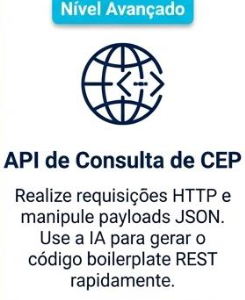

In [2]:
"""
API de consulta de CEP (Brasil) usando o serviço público ViaCEP.

Módulo responsável por validar, consultar e formatar dados de
endereço a partir de um CEP.
"""

from __future__ import annotations

import logging
import re
from dataclasses import dataclass
from functools import lru_cache
from typing import Final

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

logger = logging.getLogger(__name__)

_CEP_REGEX: Final = re.compile(r"^\d{8}$")
_BASE_URL: Final = "https://viacep.com.br/ws/{cep}/json/"
_TIMEOUT: Final = 5  # segundos


class CepError(Exception):
    """Erro base para falhas na consulta de CEP."""


class CepInvalidoError(CepError):
    """CEP não está no formato esperado (8 dígitos numéricos)."""


class CepNaoEncontradoError(CepError):
    """CEP formatado corretamente mas não existe na base do ViaCEP."""


class CepServicoIndisponivelError(CepError):
    """Falha de rede, timeout ou erro no serviço externo."""


@dataclass(frozen=True)
class Endereco:
    cep: str
    logradouro: str
    bairro: str
    localidade: str
    uf: str
    ddd: str = ""


def _normalizar_cep(cep: str) -> str:
    """Remove caracteres não numéricos (ex.: hífen) e valida o formato."""
    if not isinstance(cep, str):
        raise CepInvalidoError(
            f"CEP deve ser uma string, recebido: {type(cep).__name__}"
        )

    cep_limpo = re.sub(r"\D", "", cep)

    if not _CEP_REGEX.match(cep_limpo):
        raise CepInvalidoError(
            f"CEP inválido: '{cep}'. Esperado 8 dígitos numéricos."
        )

    return cep_limpo


def _criar_sessao() -> requests.Session:
    """Cria uma sessão HTTP com política de retry para maior resiliência."""
    sessao = requests.Session()
    retry = Retry(
        total=3,
        backoff_factor=0.5,
        status_forcelist=(500, 502, 503, 504),
        allowed_methods=("GET",),
    )
    adapter = HTTPAdapter(max_retries=retry)
    sessao.mount("https://", adapter)
    return sessao


_sessao_http = _criar_sessao()


@lru_cache(maxsize=256)
def consultar_cep(cep: str) -> Endereco:
    """
    Consulta um CEP na API pública ViaCEP e retorna um objeto Endereco.

    Args:
        cep: CEP no formato "00000000" ou "00000-000".

    Returns:
        Endereco com os dados retornados pela API.

    Raises:
        CepInvalidoError: se o CEP não tiver o formato esperado.
        CepNaoEncontradoError: se o CEP não existir na base do ViaCEP.
        CepServicoIndisponivelError: se houver falha de rede/timeout.
    """
    cep_normalizado = _normalizar_cep(cep)
    url = _BASE_URL.format(cep=cep_normalizado)

    try:
        resposta = _sessao_http.get(url, timeout=_TIMEOUT)
        resposta.raise_for_status()
    except requests.exceptions.RequestException as exc:
        logger.error("Falha ao consultar CEP %s: %s", cep_normalizado, exc)
        raise CepServicoIndisponivelError(
            f"Não foi possível consultar o CEP {cep_normalizado}: {exc}"
        ) from exc

    dados = resposta.json()

    if dados.get("erro"):
        raise CepNaoEncontradoError(f"CEP não encontrado: {cep_normalizado}")

    return Endereco(
        cep=dados.get("cep", cep_normalizado),
        logradouro=dados.get("logradouro", ""),
        bairro=dados.get("bairro", ""),
        localidade=dados.get("localidade", ""),
        uf=dados.get("uf", ""),
        ddd=dados.get("ddd", ""),
    )

consultar_cep("01001-000")

Endereco(cep='01001-000', logradouro='Praça da Sé', bairro='Sé', localidade='São Paulo', uf='SP', ddd='11')